In [1]:

import pandas as pd
import random
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import pickle

In [2]:
import pandas as pd
import random

data = []

for i in range(1000):
    practice = random.randint(1, 10)
    energy = random.randint(1, 10)
    rhythm = random.randint(1, 10)
    flexibility = random.randint(1, 10)
    stage = random.randint(1, 10)

    score = (practice + energy + rhythm + flexibility + stage) / 5

    if score >= 8.5:
        rating = "Excellent"
    elif score >= 7:
        rating = "Very Good"
    elif score >= 5.5:
        rating = "Good"
    elif score >= 4:
        rating = "Average"
    elif score >= 2.5:
        rating = "Poor"
    else:
        rating = "Bad"

    data.append([
        practice,
        energy,
        rhythm,
        flexibility,
        stage,
        rating
    ])

df = pd.DataFrame(data, columns=[
    "Practice_Hours",
    "Energy",
    "Rhythm",
    "Flexibility",
    "Stage_Presence",
    "Rating"
])

print(df.head())
print(df.shape)

   Practice_Hours  Energy  Rhythm  Flexibility  Stage_Presence   Rating
0               3       1       1            6               7     Poor
1               2       3       4           10               7  Average
2               9       5       5           10               2     Good
3               9       5       5            2               8     Good
4              10       4       2            2               6  Average
(1000, 6)


In [3]:
df.shape

(1000, 6)

In [23]:
print(df.columns)

Index(['Practice_Hours', 'Energy', 'Rhythm', 'Flexibility', 'Stage_Presence',
       'Rating'],
      dtype='object')


In [24]:
target_column = "Rating"

In [25]:
df.columns = df.columns.str.strip()

In [26]:
df = pd.get_dummies(df)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Practice_Hours  1000 non-null   int64 
 1   Energy          1000 non-null   int64 
 2   Rhythm          1000 non-null   int64 
 3   Flexibility     1000 non-null   int64 
 4   Stage_Presence  1000 non-null   int64 
 5   Rating          1000 non-null   object
dtypes: int64(5), object(1)
memory usage: 47.0+ KB


In [5]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Rating'] = le.fit_transform(df['Rating'])
df.head()

,Practice_Hours,Energy,Rhythm,Flexibility,Stage_Presence,Rating
0,3,1,1,6,7,4
1,2,3,4,10,7,0
2,9,5,5,10,2,3
3,9,5,5,2,8,3
4,10,4,2,2,6,0


In [6]:
X = df.drop('Rating',axis=1)
y = df['Rating']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,
    random_state=42
)


In [8]:
model = RandomForestClassifier()
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [9]:
prediction = model.predict(X_test)
prediction

array([0, 0, 4, 3, 4, 0, 0, 0, 0, 0, 3, 5, 3, 0, 0, 0, 0, 0, 3, 0, 0, 5,
       0, 0, 3, 0, 3, 5, 0, 0, 0, 4, 0, 0, 0, 0, 3, 3, 0, 0, 4, 0, 3, 3,
       4, 0, 3, 0, 0, 0, 3, 0, 3, 3, 5, 0, 0, 3, 3, 0, 5, 0, 0, 0, 3, 0,
       0, 3, 0, 3, 3, 0, 3, 0, 0, 0, 3, 0, 4, 0, 4, 0, 3, 0, 0, 3, 0, 3,
       0, 3, 0, 3, 0, 0, 3, 4, 0, 0, 3, 0, 0, 0, 3, 3, 0, 3, 5, 5, 0, 3,
       4, 0, 3, 3, 3, 0, 5, 3, 0, 0, 0, 3, 0, 3, 3, 0, 0, 0, 0, 3, 0, 3,
       0, 4, 0, 4, 3, 3, 0, 3, 3, 0, 0, 4, 3, 5, 0, 3, 0, 3, 3, 0, 3, 3,
       3, 0, 5, 0, 0, 0, 0, 3, 4, 5, 0, 3, 0, 0, 0, 3, 3, 0, 0, 0, 0, 3,
       4, 0, 0, 0, 0, 0, 0, 0, 3, 0, 0, 3, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       3, 3])

In [10]:
accuracy = accuracy_score(y_test,prediction)
print("Accuracy =", accuracy)

Accuracy = 0.81


In [11]:
import matplotlib.pyplot as plt


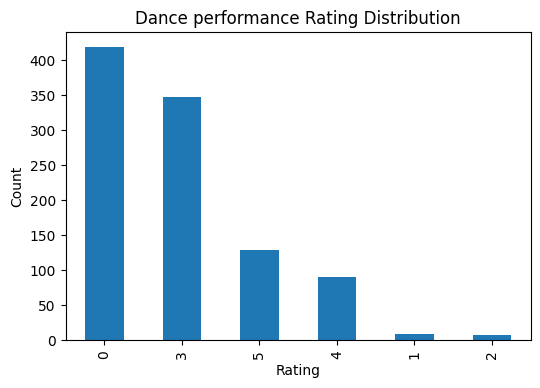

In [12]:
rating_counts = df['Rating'].value_counts()
plt.figure(figsize=(6,4))
rating_counts.plot(kind='bar')
plt.title("Dance performance Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

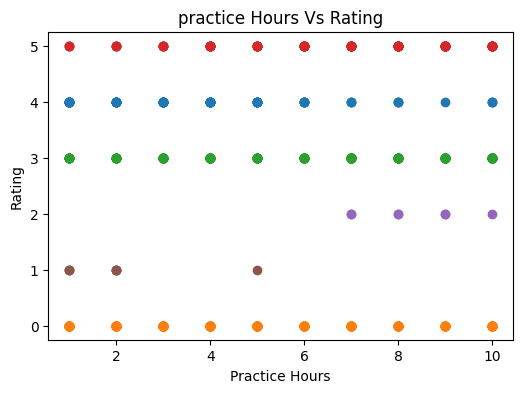

In [13]:
plt.figure(figsize=(6,4))
for rating in df['Rating'].unique():
    subset = df[df['Rating'] == rating]
    plt.scatter(subset['Practice_Hours'],[rating]*len(subset))
plt.title("practice Hours Vs Rating")
plt.xlabel("Practice Hours")
plt.ylabel("Rating")
plt.show()

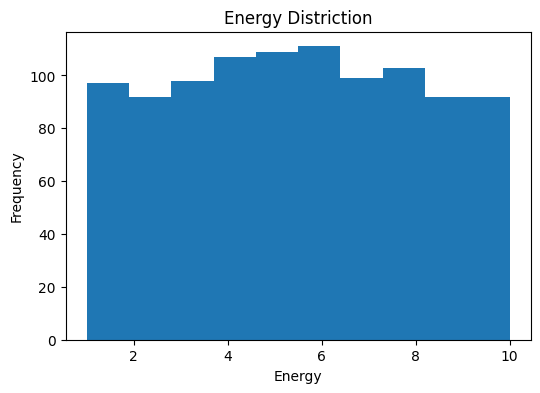

In [14]:
plt.figure(figsize=(6,4))
plt.hist(df['Energy'], bins=10)
plt.title("Energy Distriction")
plt.xlabel("Energy")
plt.ylabel("Frequency")
plt.show()

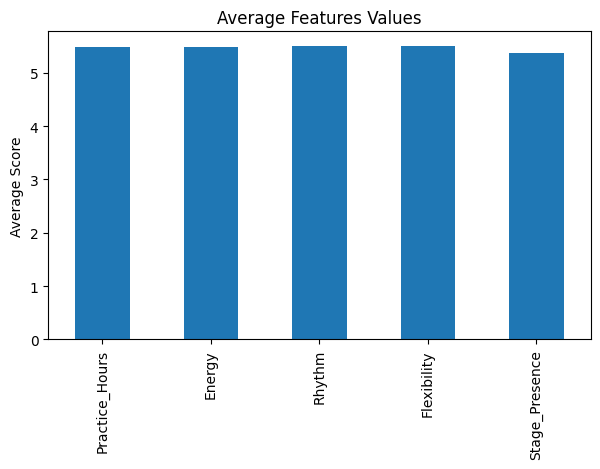

In [15]:
features =['Practice_Hours', 'Energy', 'Rhythm', 'Flexibility', 'Stage_Presence']
avg_values = df[features].mean()
plt.figure(figsize=(7,4))
avg_values.plot(kind='bar')
plt.title("Average Features Values")
plt.ylabel("Average Score")
plt.show()

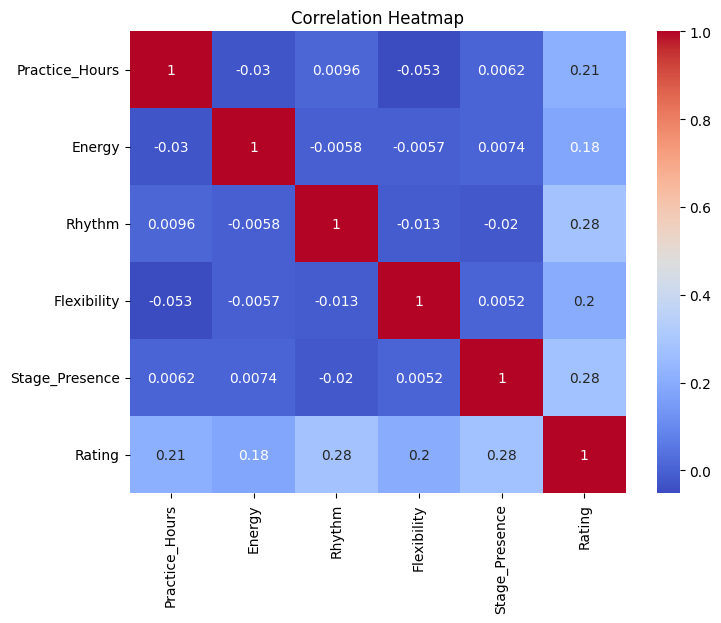

In [16]:
import seaborn as sns
numeric_df = df.copy()
le = LabelEncoder()
numeric_df['Rating'] = le.fit_transform(numeric_df['Rating'])
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [17]:
y_pred = model.predict(X_test)

In [18]:
pickle.dump(model, open("model.pkl", "wb"))

In [21]:
import pickle

model = pickle.load(open("model.pkl", "rb"))

In [22]:
model.fit(X_train, y_train)

import pickle
pickle.dump(model, open("model.pkl", "wb"))

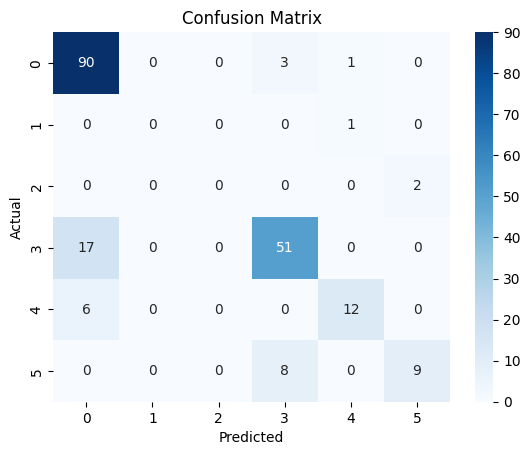

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.96      0.87        94
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.82      0.75      0.78        68
           4       0.86      0.67      0.75        18
           5       0.82      0.53      0.64        17

    accuracy                           0.81       200
   macro avg       0.55      0.48      0.51       200
weighted avg       0.80      0.81      0.80       200



C:\Users\inter\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\inter\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\inter\AppData\Roaming\Python\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital